In [1]:
import sys, os
sys.path.append("../../")  # if needed
import pandas as pd
import data_loading as dl
import numpy as np
import matplotlib.pyplot as plt

from cc0pi_cached import load_runs_with_cc0pi_bdt

In [ ]:
rundata, mc_weights, data_pot = load_runs_with_cc0pi_bdt(
    ["1"],
    model_path="/exp/uboone/app/users/rlalnunt/PELEE_BDT/cc0pi_fstrack_pid_softprob.json",
    data="bnb",
    loadshowervariables=False,
    loadnumuvariables=True,
    load_numu_tki=False,
    loadpi0variables=False,
    loadrecoveryvars=False,
    loadsystematics=True,
    blinded=True,
    enable_cache=True,   # turns on the HDF cache
    overwrite=False,      # don’t overwrite cached result
    use_bdt=False
)

Loading run 1
Running the CC0pi-BDT....


In [3]:
mc = rundata["mc"]

In [33]:
#print(mc)
print("is_mc" in rundata["mc"].columns)
#print(mc["mc_num_protons"].values)  
print(len(mc["is_mc"]))


True
1020773


## NOTE::: THis IS_SIGNAL and other which exist in data_loading.py needs to be rename to avoid confusion with BDT
#### ALSO, check properly the code,  eg: "trk_bragg_mu_fwd_preferred_v" is not read correclty in the code


## DEBUG

In [24]:
need = [
  "mc_nu_pdg","nu_pdg","truth_nu_pdg",
  "mc_ccnc","ccnc",
  "mc_nu_vtx_x","true_nu_vtx_x",
  "mc_nu_vtx_y","true_nu_vtx_y",
  "mc_nu_vtx_z","true_nu_vtx_z",
  "mc_pdg","mc_E","mc_px","mc_py","mc_pz",
]
print({c: (c in mc.columns) for c in need})

print("is_mc counts:\n", mc["is_mc"].fillna(False).value_counts(dropna=False))

for c in ["mc_is_signal","mc_vertex_in_FV","mc_neutrino_is_numu",
          "mc_muon_in_mom_range","mc_lead_p_in_mom_range","mc_no_fs_mesons"]:
    if c in mc.columns:
        print(f"{c} true count:", mc[c].fillna(False).sum())


{'mc_nu_pdg': False, 'nu_pdg': True, 'truth_nu_pdg': False, 'mc_ccnc': False, 'ccnc': True, 'mc_nu_vtx_x': False, 'true_nu_vtx_x': True, 'mc_nu_vtx_y': False, 'true_nu_vtx_y': True, 'mc_nu_vtx_z': False, 'true_nu_vtx_z': True, 'mc_pdg': False, 'mc_E': False, 'mc_px': False, 'mc_py': False, 'mc_pz': False}
is_mc counts:
 True    1020773
Name: is_mc, dtype: int64
mc_is_signal true count: 0
mc_vertex_in_FV true count: 279268
mc_neutrino_is_numu true count: 1010310
mc_muon_in_mom_range true count: 0
mc_lead_p_in_mom_range true count: 0
mc_no_fs_mesons true count: 1020773


In [25]:
print("has is_mc:", "is_mc" in mc.columns)
print("has mc_is_signal:", "mc_is_signal" in mc.columns)
if "mc_is_signal" in mc.columns:
    print(mc["mc_is_signal"].value_counts(dropna=False).head())


has is_mc: True
has mc_is_signal: True
False    1020773
Name: mc_is_signal, dtype: int64


In [45]:
import numpy as np
import pandas as pd

def _b(x):  # safe bool
    return x.fillna(False).astype(bool)

def compute_eff_pur_df(df: pd.DataFrame) -> pd.DataFrame:
    # selection
    stages = [
        ("no cuts",                                       lambda d: d["is_mc"]==d["is_mc"]),  # always True
        ("in FV",                                         lambda d: _b(d["sel_reco_vertex_in_FV"])),
        ("starts contained",                              lambda d: _b(d["sel_reco_vertex_in_FV"]) & _b(d["sel_pfp_starts_in_PCV"])),
        ("CCincl",                                        lambda d: _b(d["sel_nu_mu_cc"])),
        ("#mu momentum limits",                           lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_muon_passed_mom_cuts"])),
        ("no showers",                                    lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"])),
        ("#mu contained",                                 lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"]) & _b(d["sel_muon_contained"])),
        ("#mu quality",                                   lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"]) & _b(d["sel_muon_contained"]) & _b(d["sel_muon_quality_ok"])),
        ("has p candidate",                               lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"]) & _b(d["sel_muon_contained"]) & _b(d["sel_muon_quality_ok"]) & _b(d["sel_has_p_candidate"])),
        ("p contained",                                   lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"]) & _b(d["sel_muon_contained"]) & _b(d["sel_muon_quality_ok"]) & _b(d["sel_has_p_candidate"]) & _b(d["sel_protons_contained"])),
        ("proton PID",                                    lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"]) & _b(d["sel_muon_contained"]) & _b(d["sel_muon_quality_ok"]) & _b(d["sel_has_p_candidate"]) & _b(d["sel_protons_contained"]) & _b(d["sel_passed_proton_pid_cut"])),
        ("p momentum limits (== sel_CC1p0pi)",            lambda d: _b(d["sel_CC1p0pi"])),
    ]

    mc  = _b(df["is_mc"])
    sig = _b(df["mc_is_signal"]) & mc  # C++ uses signal = "mc_is_signal && is_mc"

    rows = []
    for idx, (name, sel_fun) in enumerate(stages, start=1):
        sel = sel_fun(df) & mc                      # selection && is_mc
        num_signal           = int(sig.sum())       # denominator for efficiency
        num_selected         = int(sel.sum())       # denominator for purity
        num_selected_signal  = int((sig & sel).sum())

        eff = (num_selected_signal / num_signal)   if num_signal   else np.nan
        pur = (num_selected_signal / num_selected) if num_selected else np.nan

        rows.append(dict(
            step=idx, stage=name,
            num_signal=num_signal,
            num_selected=num_selected,
            num_selected_signal=num_selected_signal,
            efficiency=eff, purity=pur,
        ))

    return pd.DataFrame(rows)

# Example:
results = compute_eff_pur_df(mc)  # df contains your selection booleans from apply_ccnp0pi_stv(...)
print(results)


    step                               stage  num_signal  num_selected  \
0      1                             no cuts           0       1020773   
1      2                               in FV           0        229267   
2      3                    starts contained           0        209115   
3      4                              CCincl           0         96069   
4      5                 #mu momentum limits           0         93743   
5      6                          no showers           0         93743   
6      7                       #mu contained           0         41713   
7      8                         #mu quality           0         31322   
8      9                     has p candidate           0         18230   
9     10                         p contained           0         18230   
10    11                          proton PID           0         18230   
11    12  p momentum limits (== sel_CC1p0pi)           0         13182   

    num_selected_signal  efficiency  

In [46]:
import numpy as np
import pandas as pd

def _b(s: pd.Series) -> pd.Series:
    return s.fillna(False).astype(bool)

def compute_eff_pur_df(df: pd.DataFrame) -> pd.DataFrame:
    # stages are cumulative (each lambda already includes previous cuts)
    stages = [
        ("no cuts",                          lambda d: pd.Series(True, index=d.index)),
        ("in FV",                            lambda d: _b(d["sel_reco_vertex_in_FV"])),
        ("starts contained",                 lambda d: _b(d["sel_reco_vertex_in_FV"]) & _b(d["sel_pfp_starts_in_PCV"])),
        ("CCincl",                           lambda d: _b(d["sel_nu_mu_cc"])),
        ("#mu momentum limits",              lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_muon_passed_mom_cuts"])),
        ("no showers",                       lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"])),
        ("#mu contained",                    lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"]) & _b(d["sel_muon_contained"])),
        ("#mu quality",                      lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"]) & _b(d["sel_muon_contained"]) & _b(d["sel_muon_quality_ok"])),
        ("has p candidate",                  lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"]) & _b(d["sel_muon_contained"]) & _b(d["sel_muon_quality_ok"]) & _b(d["sel_has_p_candidate"])),
        ("p contained",                      lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"]) & _b(d["sel_muon_contained"]) & _b(d["sel_muon_quality_ok"]) & _b(d["sel_has_p_candidate"]) & _b(d["sel_protons_contained"])),
        ("proton PID",                       lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"]) & _b(d["sel_muon_contained"]) & _b(d["sel_muon_quality_ok"]) & _b(d["sel_has_p_candidate"]) & _b(d["sel_protons_contained"]) & _b(d["sel_passed_proton_pid_cut"])),
        ("p momentum limits (== sel_CC1p0pi)", lambda d: _b(d["sel_CC1p0pi"])),
    ]

    mc  = _b(df["is_mc"])                        # use MC-only for truth-based metrics
    sig = _b(df["mc_is_signal"]) & mc            # your signal definition from _categorize_mc

    rows = []
    for i, (name, sel_fun) in enumerate(stages, start=1):
        sel = sel_fun(df) & mc

        n_sig_total   = int(sig.sum())                  # denominator for efficiency
        n_sel_total   = int(sel.sum())                  # denominator for purity
        n_sel_signal  = int((sig & sel).sum())

        eff = (n_sel_signal / n_sig_total) if n_sig_total else np.nan
        pur = (n_sel_signal / n_sel_total) if n_sel_total else np.nan

        rows.append(dict(
            step=i, stage=name,
            num_signal=n_sig_total,
            num_selected=n_sel_total,
            num_selected_signal=n_sel_signal,
            efficiency=eff, purity=pur,
        ))
    return pd.DataFrame(rows)


In [48]:
results = compute_eff_pur_df(mc)   # df is your full event table
print(results)
# Final-row efficiency/purity for sel_CC1p0pi:
print(results.tail(1)[["efficiency","purity"]])


    step                               stage  num_signal  num_selected  \
0      1                             no cuts           0       1020773   
1      2                               in FV           0        229267   
2      3                    starts contained           0        209115   
3      4                              CCincl           0         96069   
4      5                 #mu momentum limits           0         93743   
5      6                          no showers           0         93743   
6      7                       #mu contained           0         41713   
7      8                         #mu quality           0         31322   
8      9                     has p candidate           0         18230   
9     10                         p contained           0         18230   
10    11                          proton PID           0         18230   
11    12  p momentum limits (== sel_CC1p0pi)           0         13182   

    num_selected_signal  efficiency  

In [50]:
def eff_pur_for(df: pd.DataFrame, sel_col="sel_CC1p0pi",
                sig_col="mc_is_signal", mc_col="is_mc"):
    mc  = _b(df[mc_col])
    sig = _b(df[sig_col]) & mc
    sel = _b(df[sel_col]) & mc

    n_sig_total  = sig.sum()
    n_sel_total  = sel.sum()
    n_sel_sig    = (sig & sel).sum()

    eff = float(n_sel_sig / n_sig_total) if n_sig_total else np.nan
    pur = float(n_sel_sig / n_sel_total) if n_sel_total else np.nan
    return dict(
        num_signal=int(n_sig_total),
        num_selected=int(n_sel_total),
        num_selected_signal=int(n_sel_sig),
        efficiency=eff, purity=pur
    )

headline = eff_pur_for(mc)
print(headline)


{'num_signal': 0, 'num_selected': 13182, 'num_selected_signal': 0, 'efficiency': nan, 'purity': 0.0}


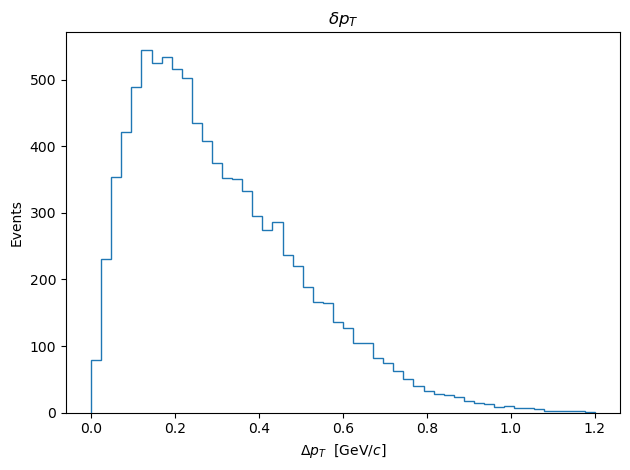

In [20]:
import matplotlib.pyplot as plt
plt.figure()
plt.hist(mc["delta_pT"], bins=50, range=(0, 1.2), weights=mc["weights"], histtype="step", density=False)
plt.xlabel(r"$\Delta p_T$  [GeV/$c$]")
plt.ylabel("Events")
plt.title("$\delta$$p_T$")
plt.tight_layout()

### Selection Efficiency

In [12]:
import numpy as np
import pandas as pd

# ---------- weights ----------
def get_event_weights(df: pd.DataFrame) -> np.ndarray:
    # If you've already built a single "weights" column, use it.
    if "weights" in df:
        w = pd.to_numeric(df["weights"], errors="coerce")
    else:
        # Otherwise try the standard PeLEE components; fall back to 1.0 if missing.
        parts = []
        for c in ["weightsGenie", "weightsFlux", "weightsReint"]:
            if c in df.columns:
                parts.append(pd.to_numeric(df[c], errors="coerce").fillna(1.0))
        if parts:
            w = parts[0].copy()
            for p in parts[1:]:
                w = w * p
        else:
            w = pd.Series(1.0, index=df.index)
    return w.fillna(0.0).astype(float).to_numpy()

# ---------- helper to pick the best-available truth columns ----------
def _pick_numeric(df, names, default=None):
    for n in names:
        if n in df.columns:
            return pd.to_numeric(df[n], errors="coerce")
    return default

# ---------- build truth masks ----------
def build_truth_masks(mc: pd.DataFrame):
    ccnc    = _pick_numeric(mc, ["ccnc"])
    nu_pdg  = _pick_numeric(mc, ["nu_pdg"])
    nproton = _pick_numeric(mc, ["nproton"])
    npi0    = _pick_numeric(mc, ["npi0"])
                            #default=pd.Series(0, index=mc.index))
    npion   = _pick_numeric(mc, ["npion"])
    nmuon   = _pick_numeric(mc, ["nmuon"])
#     npi_ch = _pick_numeric(mc, ["npi", "npi_pm", "npi_charged", "n_pi_ch"])
#     if npi_ch is None:
#         npi_plus  = _pick_numeric(mc, ["npi_plus", "n_pi_plus", "npi+"])
#         npi_minus = _pick_numeric(mc, ["npi_minus", "n_pi_minus", "npi-"])
#         if (npi_plus is not None) and (npi_minus is not None):
#             npi_ch = (npi_plus.fillna(0) + npi_minus.fillna(0))
#         else:
#             npi_ch = pd.Series(0, index=mc.index)  # conservative fallback

    # CC numu
    is_cc_numu = ((ccnc.fillna(1) == 0) & (nu_pdg.fillna(0) == 14))

    # Physics truth categories
    truth_0piNp  = (is_cc_numu & (nmuon.fillna(0) == 1) & (npion.fillna(0) == 0) & (npi0.fillna(0) == 0) & (nproton.fillna(0) >= 1))
    truth_1p0pi  = (is_cc_numu & (nmuon.fillna(0) == 1) &  (npion.fillna(0) == 0) & (npi0.fillna(0) == 0) & (nproton.fillna(0) == 1))

    return truth_0piNp.to_numpy(), truth_1p0pi.to_numpy()

# ---------- generic metric function ----------
def eff_pur_for_selection(mc: pd.DataFrame, sel_col: str, truth_mask: np.ndarray, w: np.ndarray):
    if sel_col not in mc.columns:
        raise KeyError(f"Selection column '{sel_col}' not found in DataFrame.")
    sel_mask = mc[sel_col].astype(bool).to_numpy()
    
    tot_sig = float(w[truth_mask].sum())                    # total true in category
    sel_sig = float(w[truth_mask & sel_mask].sum())         # selected true
    sel_all = float(w[sel_mask].sum())                      # all selected (sig + bkg)

    efficiency = (sel_sig / tot_sig) * 100 if tot_sig > 0 else 0.0
    purity     = (sel_sig / sel_all) * 100 if sel_all > 0 else 0.0
    return dict(tot_sig=tot_sig, sel_sig=sel_sig, sel_all=sel_all,
                efficiency=efficiency, purity=purity)

# ===== run it =====
w = get_event_weights(mc)
truth_0piNp, truth_1p0pi = build_truth_masks(mc)

res_np0pi  = eff_pur_for_selection(mc, "sel_CCNp0pi",  truth_0piNp,  w)
res_1p0pi  = eff_pur_for_selection(mc, "sel_CC1p0pi",  truth_1p0pi,  w)

print("[CCNp0pi]  total={tot_sig:.3f}, selected_true={sel_sig:.3f}, selected_all={sel_all:.3f}".format(**res_np0pi))
print("           Efficiency={efficiency:.2f}%, Purity={purity:.2f}%".format(**res_np0pi))

print("[CC1p0pi]  total={tot_sig:.3f}, selected_true={sel_sig:.3f}, selected_all={sel_all:.3f}".format(**res_1p0pi))
print("           Efficiency={efficiency:.2f}%, Purity={purity:.2f}%".format(**res_1p0pi))


[CCNp0pi]  total=69957.198, selected_true=2241.881, selected_all=2941.294
           Efficiency=3.20%, Purity=76.22%
[CC1p0pi]  total=49454.622, selected_true=1352.517, selected_all=2111.524
           Efficiency=2.73%, Purity=64.05%


In [13]:
import pandas as pd
import numpy as np

ccnc = pd.Series([0, 1, np.nan, 0])

# Scenario 1: Using fillna(1)
filled_with_1 = (ccnc.fillna(0) == 0)
result_1 = filled_with_1

# Scenario 2: Using fillna(0)
filled_with_0 = (ccnc.fillna(1) == 0)
result_2 = filled_with_0

print(f"Original Series:\n{ccnc}\n")
print(f"Result of ccnc.fillna(0) == 0:\n{result_1}\n")
print(f"Result of ccnc.fillna(1) == 0:\n{result_2}\n")


Original Series:
0    0.0
1    1.0
2    NaN
3    0.0
dtype: float64

Result of ccnc.fillna(0) == 0:
0     True
1    False
2     True
3     True
dtype: bool

Result of ccnc.fillna(1) == 0:
0     True
1    False
2    False
3     True
dtype: bool



### Old+New combine

In [14]:
import numpy as np
import pandas as pd

# ---- weights ----
def get_event_weights(df: pd.DataFrame) -> np.ndarray:
    if "weights" in df.columns:
        w = pd.to_numeric(df["weights"], errors="coerce")
    else:
        parts = []
        for c in ["weightsGenie", "weightsFlux", "weightsReint"]:
            if c in df.columns:
                parts.append(pd.to_numeric(df[c], errors="coerce").fillna(1.0))
        if parts:
            w = parts[0].copy()
            for p in parts[1:]:
                w = w * p
        else:
            w = pd.Series(1.0, index=df.index)
    return w.fillna(0.0).astype(float).to_numpy()

def _pick_numeric(df: pd.DataFrame, names, default_val=0):
    for n in names:
        if n in df.columns:
            return pd.to_numeric(df[n], errors="coerce")
    return pd.Series(default_val, index=df.index, dtype=float)

# ---- build truth from category_fixed ----
def build_truth_masks_from_category_fixed(mc: pd.DataFrame):
    if "category_fixed" not in mc.columns:
        raise KeyError("category_fixed not found in DataFrame")

    # Constants from old code
    k_nu_mu_other = 2   # numu CC, no pi0 (FV & ≥1 true muon already implied by how category_fixed was built)

    base_numu_no_pi0 = (mc["category_fixed"] == k_nu_mu_other)

    # Charged-pion veto and proton counts
    npion   = _pick_numeric(mc, ["npion", "npi_ch", "n_pi_ch"], default_val=0)
    nproton = _pick_numeric(mc, ["nproton"], default_val=0)

    no_charged_pi = (npion.fillna(0) == 0)

    # Truth definitions matching old intent:
    # 1muNp0pi: numu CC, FV, ≥1 true muon, no pi0 (via category_fixed==2), no charged pion, ≥1 proton
    truth_0piNp = (base_numu_no_pi0 & no_charged_pi & (nproton.fillna(0) >= 1))

    # 1mu1p0pi: same, but exactly one proton
    truth_1p0pi = (base_numu_no_pi0 & no_charged_pi & (nproton.fillna(0) == 1))

    return truth_0piNp.to_numpy(), truth_1p0pi.to_numpy()

# ---- metrics ----
def eff_pur_for_selection(mc: pd.DataFrame, sel_col: str, truth_mask: np.ndarray, w: np.ndarray):
    if sel_col not in mc.columns:
        raise KeyError(f"Selection column '{sel_col}' not found in DataFrame.")
    sel_mask = mc[sel_col].astype(bool).to_numpy()

    tot_sig = float(w[truth_mask].sum())
    sel_sig = float(w[truth_mask & sel_mask].sum())
    sel_all = float(w[sel_mask].sum())

    efficiency = (sel_sig / tot_sig) * 100 if tot_sig > 0 else 0.0
    purity     = (sel_sig / sel_all) * 100 if sel_all > 0 else 0.0
    return dict(tot_sig=tot_sig, sel_sig=sel_sig, sel_all=sel_all,
                efficiency=efficiency, purity=purity)

# ===== run it on MC DataFrame =====
w = get_event_weights(mc)
truth_0piNp, truth_1p0pi = build_truth_masks_from_category_fixed(mc)

res_np0pi  = eff_pur_for_selection(mc, "sel_CCNp0pi", truth_0piNp,  w)   # 1muNp0pi
res_1p0pi  = eff_pur_for_selection(mc, "sel_CC1p0pi", truth_1p0pi,  w)   # 1mu1p0pi

print("[CCNp0pi]  total={tot_sig:.3f}, selected_true={sel_sig:.3f}, selected_all={sel_all:.3f}"
      .format(**res_np0pi))
print("           Efficiency={efficiency:.2f}%, Purity={purity:.2f}%"
      .format(**res_np0pi))

print("[CC1p0pi]  total={tot_sig:.3f}, selected_true={sel_sig:.3f}, selected_all={sel_all:.3f}"
      .format(**res_1p0pi))
print("           Efficiency={efficiency:.2f}%, Purity={purity:.2f}%"
      .format(**res_1p0pi))


[CCNp0pi]  total=23349.461, selected_true=2231.487, selected_all=2941.294
           Efficiency=9.56%, Purity=75.87%
[CC1p0pi]  total=16516.860, selected_true=1346.161, selected_all=2111.524
           Efficiency=8.15%, Purity=63.75%


In [ ]:
print (mc["category"] == 1)